# 07 Comparative results

Regression models are evaluated on the same converged test states. Feasibility classifiers are evaluated on all test states, with unresolved numerical regimes labeled inadmissible. Tables combine predictive accuracy, probability calibration, topology-fold variability, uncertainty, resource costs and paired statistical comparisons.

The topology test was examined during model development. Training-only OOF evaluation and the separate external-feeder experiment provide complementary checks of generalization.

In [1]:
from pathlib import Path
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT = Path.cwd()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
assert (PROJECT / "src" / "models.py").is_file()
sys.path.insert(0, str(PROJECT))
from src.notebook_tools import configure_style, show_table, save_figure
from src.protocol import SEED, SEEDS, FULL_CONFIG, TRAINING, MODEL_ORDER

configure_style()
rng = np.random.default_rng(SEED)
FIGURES = PROJECT / "figures"
TABLES = PROJECT / "artifacts" / "generated" / "tables"
RESULTS = PROJECT / "artifacts" / "generated" / "results"
MODELS = PROJECT / "artifacts" / "generated" / "models"
for directory in (FIGURES, TABLES, RESULTS, MODELS):
    directory.mkdir(parents=True, exist_ok=True)


from src.models import DatasetBundle, load_bundle, split_indices, predict_graph_model
from src.protocol import (
    regression_metrics,
    probability_metrics,
    fit_tabular,
    predict_tabular,
    train_graph,
    save_graph,
    inner_group_selection,
    measure_resources,
    cluster_bootstrap,
    holm_adjust,
    calibrate_probability,
)

bundle = load_bundle(PROJECT / "dataset" / "processed")
metadata = bundle.metadata
indices = split_indices(bundle)
all_indices = np.arange(len(metadata))
valid_test = indices["test"][metadata.iloc[indices["test"]].converged.to_numpy() == 1]
fold_manifest = pd.read_csv(PROJECT / "dataset" / "processed" / "topology_folds.csv")
fold_id = fold_manifest.set_index("sample_id").loc[metadata.sample_id, "fold"].to_numpy()


def prediction_path(name: str) -> Path:
    """Use the same unambiguous model identifier throughout the study."""
    return RESULTS / (name.replace(" ", "_") + "_predictions.npz")


def load_predictions(name: str) -> tuple[np.ndarray, np.ndarray]:
    stored = np.load(prediction_path(name))
    assert np.array_equal(stored["sample_id"], metadata.sample_id.to_numpy())
    return stored["prediction"], stored["probability"]

In [2]:
from src.protocol import regression_metrics, probability_metrics
from scipy.stats import wilcoxon

all_regression = []
for name in MODEL_ORDER:
    values, _ = load_predictions(name)
    all_regression.append(
        dict(
            model=name,
            split="test converged",
            n=len(valid_test),
            **regression_metrics(bundle.targets[valid_test], values[valid_test])
        )
    )
final_regression = pd.DataFrame(all_regression)
calibrated = np.load(RESULTS / "calibrated_test_probabilities.npz")
import joblib

probability_rows = []
for name in MODEL_ORDER:
    calibration = joblib.load(MODELS / (name.replace(" ", "_") + "_calibration.joblib"))
    probability_rows.append(
        dict(
            model=name,
            split="test",
            n=len(indices["test"]),
            **probability_metrics(
                bundle.targets[indices["test"], 2], calibrated[name], calibration["threshold"]
            )
        )
    )
final_probability = pd.DataFrame(probability_rows)

## Primary voltage comparison

Voltage accuracy is compared on the common converged test set.

In [3]:
voltage = final_regression[["model", "split", "n", "vmin_rmse", "vmin_mae", "vmin_r2"]].copy()
voltage["rmse_rank"] = voltage.vmin_rmse.rank(method="min").astype(int)
show_table(
    voltage,
    ["model", "split", "n"],
    {"Voltage accuracy (errors ↓, R² ↑)": ["vmin_rmse", "vmin_mae", "vmin_r2", "rmse_rank"]},
    TABLES / "07_voltage.csv",
    digits=6,
)
best = voltage.loc[voltage.vmin_rmse.idxmin()]
proposed = voltage[voltage.model.eq("ACG-MAC Ensemble")].iloc[0]

model,split,n,vmin_rmse,vmin_mae,vmin_r2,rmse_rank
LinearDistFlow,test converged,605,0.020858,0.008972,0.927410,9
Ridge,test converged,605,0.009549,0.003443,0.984784,3
RandomForest,test converged,605,0.013573,0.004190,0.969261,5
ExtraTrees,test converged,605,0.018995,0.005976,0.939796,8
MLP,test converged,605,0.011701,0.005446,0.977156,4
XGBoost,test converged,605,0.016909,0.004876,0.952292,7
LightGBM,test converged,605,0.016672,0.004202,0.953624,6
GCN Direct,test converged,605,0.023381,0.013531,0.908788,10
Physics-Residual GCN,test converged,605,0.008909,0.003787,0.986757,2
ACG-MAC Ensemble,test converged,605,0.006698,0.002405,0.992514,1


Voltage errors and the descriptive RMSE rank use the same converged test observations. Rank order alone does not establish statistical significance.

## Primary loss comparison

Active-loss accuracy is compared on the same converged test set.

In [4]:
loss = final_regression[
    ["model", "split", "n", "loss_rmse_kw", "loss_mae_kw", "loss_r2"]
].copy()
loss["rmse_rank"] = loss.loss_rmse_kw.rank(method="min").astype(int)
show_table(
    loss,
    ["model", "split", "n"],
    {"Loss accuracy (errors ↓, R² ↑)": ["loss_rmse_kw", "loss_mae_kw", "loss_r2", "rmse_rank"]},
    TABLES / "07_loss.csv",
    digits=6,
)
best = loss.loc[loss.loss_rmse_kw.idxmin()]

model,split,n,loss_rmse_kw,loss_mae_kw,loss_r2,rmse_rank
LinearDistFlow,test converged,605,132.268465,46.214976,0.737799,10
Ridge,test converged,605,47.494252,20.853615,0.966193,2
RandomForest,test converged,605,90.516166,19.880342,0.877207,7
ExtraTrees,test converged,605,125.869230,32.302411,0.762556,9
MLP,test converged,605,38.428515,14.377052,0.977868,1
XGBoost,test converged,605,79.951621,17.580177,0.904198,5
LightGBM,test converged,605,105.586797,21.595979,0.832914,8
GCN Direct,test converged,605,88.479759,45.415167,0.882670,6
Physics-Residual GCN,test converged,605,58.330145,15.700910,0.949007,4
ACG-MAC Ensemble,test converged,605,48.771030,12.559648,0.964351,3


Loss RMSE and MAE emphasize different aspects of the error distribution. Their ordering need not match the voltage ranking.

## Probability quality and calibration

Discrimination, probability errors and calibration slope are reported separately.

In [5]:
show_table(
    final_probability,
    ["model", "split", "n"],
    {
        "Discrimination ↑": ["auroc", "auprc", "f1"],
        "Probability errors ↓": ["brier", "log_loss", "ece"],
        "Calibration slope (ideal 1)": ["calibration_slope"],
    },
    TABLES / "07_probability.csv",
    digits=6,
)

model,split,n,auroc,auprc,f1
LinearDistFlow,test,618,0.992901,0.946970,0.972763
Ridge,test,618,0.998118,0.992582,0.945736
RandomForest,test,618,0.999838,0.999372,0.984127
ExtraTrees,test,618,0.998523,0.994313,0.949416
MLP,test,618,0.999059,0.996535,0.942529
XGBoost,test,618,0.999789,0.999157,0.984127
LightGBM,test,618,0.998475,0.989838,0.984127
GCN Direct,test,618,0.949955,0.835191,0.732673
Physics-Residual GCN,test,618,0.977704,0.923033,0.832117
ACG-MAC Ensemble,test,618,0.995067,0.978897,0.871080


Probability mappings and thresholds use calibration data only. Discrimination, probability error and calibration slope measure different classifier properties.

## OOF topology robustness

Three training-only folds measure performance on omitted topology groups.

In [6]:
oof = pd.concat(
    [
        pd.read_csv(RESULTS / filename)
        for filename in ["baseline_oof.csv", "graph_oof.csv", "acg_oof.csv"]
    ],
    ignore_index=True,
)
summary = (
    oof.groupby(["model", "split"], sort=False)
    .agg(
        n=("n", "sum"),
        folds=("fold", "nunique"),
        vmin_rmse_mean=("vmin_rmse", "mean"),
        vmin_rmse_sd=("vmin_rmse", "std"),
        loss_rmse_mean_kw=("loss_rmse_kw", "mean"),
        loss_rmse_sd_kw=("loss_rmse_kw", "std"),
    )
    .reset_index()
)
show_table(
    summary,
    ["model", "split", "n"],
    {
        "Fold variation (unweighted fold means)": [
            "folds",
            "vmin_rmse_mean",
            "vmin_rmse_sd",
            "loss_rmse_mean_kw",
            "loss_rmse_sd_kw",
        ]
    },
    TABLES / "07_oof.csv",
    digits=6,
)

model,split,n,folds,vmin_rmse_mean,vmin_rmse_sd,loss_rmse_mean_kw,loss_rmse_sd_kw
LinearDistFlow,training OOF,2146,3,0.009803,0.003452,48.702348,21.134253
Ridge,training OOF,2146,3,0.003023,0.000635,56.805745,28.214923
RandomForest,training OOF,2146,3,0.004325,0.001210,28.173668,27.700409
ExtraTrees,training OOF,2146,3,0.004437,0.001259,28.310447,28.435676
MLP,training OOF,2146,3,0.006990,0.000633,25.800961,19.532991
XGBoost,training OOF,2146,3,0.004248,0.001577,18.949297,20.178984
LightGBM,training OOF,2146,3,0.004392,0.002577,26.803458,26.267092
GCN Direct,training OOF,2146,3,0.022264,0.005331,85.656932,51.036156
Physics-Residual GCN,training OOF,2146,3,0.003710,0.000629,12.387243,5.493546
ACG-MAC Ensemble,training OOF,2146,3,0.002695,0.000562,12.376329,5.390870


These are means and standard deviations across three topology folds, not a pooled RMSE or an independent confidence interval. OOF and test rankings can differ because their topologies differ.

## Uncertainty calibration

Empirical coverage and interval width are compared by target and calibration method.

In [7]:
uncertainty = pd.read_csv(RESULTS / "uncertainty.csv")
show_table(
    uncertainty,
    ["model", "split", "n", "method", "target"],
    {"Interval calibration": ["nominal", "coverage", "mean_width", "pinaw"]},
    TABLES / "07_uncertainty.csv",
    digits=6,
)
coverage_values = uncertainty.coverage

model,split,n,method,target,nominal,coverage,mean_width,pinaw
ACG-MAC Ensemble,test converged,605,Global,Vmin,0.900000,0.833058,0.005399,0.010892
ACG-MAC Ensemble,test converged,605,Global,Loss kW,0.900000,0.884298,22.937294,0.011613
ACG-MAC Ensemble,test converged,605,Proxy-regime stratified,Vmin,0.900000,0.864463,0.006108,0.012323
ACG-MAC Ensemble,test converged,605,Proxy-regime stratified,Loss kW,0.900000,0.910744,31.282303,0.015838


Empirical interval coverage varies by target and calibration method. Nominal coverage is not guaranteed when calibration and test topologies follow different distributions.

## Component comparison

Matched-seed ablations quantify changes in regression error and capacity.

In [8]:
ablation_summary = pd.read_csv(TABLES / "05_ablations.csv")
full = ablation_summary[ablation_summary.model.eq("Full single member")].iloc[0]
ablation_summary["delta_voltage_rmse"] = ablation_summary.vmin_rmse_mean - full.vmin_rmse_mean
ablation_summary["delta_loss_rmse_kw"] = (
    ablation_summary.loss_rmse_mean_kw - full.loss_rmse_mean_kw
)
show_table(
    ablation_summary,
    ["model", "split", "n"],
    {
        "Voltage across seeds ↓": ["vmin_rmse_mean", "vmin_rmse_sd", "delta_voltage_rmse"],
        "Losses across seeds ↓": ["loss_rmse_mean_kw", "loss_rmse_sd_kw", "delta_loss_rmse_kw"],
        "Capacity and replication": ["seeds", "parameters"],
    },
    TABLES / "07_ablations.csv",
    digits=6,
)
without_auxiliary = ablation_summary[ablation_summary.model.eq("No auxiliary loss")].iloc[0]

model,split,n,vmin_rmse_mean,vmin_rmse_sd,delta_voltage_rmse
Full single member,test converged,605,0.007498,0.001140,0.000000
No learned reliability,test converged,605,0.007071,0.001295,−0.000427
No physics residual,test converged,605,0.022449,0.004563,0.014951
No graph propagation,test converged,605,0.007794,0.000925,0.000296
No auxiliary loss,test converged,605,0.005291,0.000550,−0.002207
Adaptive context gate control,test converged,605,0.007488,0.002422,−0.000010
No scaled regression loss,test converged,605,0.013250,0.005734,0.005752
No dropout or weight decay,test converged,605,0.006945,0.000868,−0.000553
Parameter-matched node MLP,test converged,605,0.007642,0.001322,0.000144
Physical component only,test converged,605,0.020858,Not applicable,0.013360


The matched-seed controls show a regression trade-off from the auxiliary classification loss: removing it improves voltage and loss RMSE in these runs. Component effects should be interpreted against the full single member rather than the five-member ensemble.

## Paired statistical comparison

Paired effects are evaluated with cluster intervals, multiplicity correction and practical margins.

In [9]:
statistics = pd.read_csv(RESULTS / "paired_statistics.csv")
view = statistics[
    [
        "model",
        "baseline",
        "split",
        "n",
        "target",
        "mean_difference",
        "ci_low",
        "ci_high",
        "p_holm",
        "practical_margin",
        "practical_gain_supported",
    ]
]
show_table(
    view,
    ["model", "baseline", "split", "n", "target"],
    {
        "Effect and topology-cluster CI": ["mean_difference", "ci_low", "ci_high"],
        "Multiplicity and practical criterion": [
            "p_holm",
            "practical_margin",
            "practical_gain_supported",
        ],
    },
    TABLES / "07_statistics.csv",
    digits=6,
)

model,baseline,split,n,target,mean_difference,ci_low,ci_high
ACG-MAC Ensemble,LinearDistFlow,test converged,605,Vmin MAE,−0.006567,−0.014588,−0.001754
ACG-MAC Ensemble,LinearDistFlow,test converged,605,Loss MAE kW,−33.655327,−77.120124,−9.760863
ACG-MAC Ensemble,Ridge,test converged,605,Vmin MAE,−0.001038,−0.002574,−0.000171
ACG-MAC Ensemble,Ridge,test converged,605,Loss MAE kW,−8.293966,−13.523493,−3.620196
ACG-MAC Ensemble,RandomForest,test converged,605,Vmin MAE,−0.001785,−0.004547,−0.000348
ACG-MAC Ensemble,RandomForest,test converged,605,Loss MAE kW,−7.320694,−22.841069,0.232721
ACG-MAC Ensemble,ExtraTrees,test converged,605,Vmin MAE,−0.003571,−0.010566,−0.000191
ACG-MAC Ensemble,ExtraTrees,test converged,605,Loss MAE kW,−19.742763,−62.301636,0.536300
ACG-MAC Ensemble,MLP,test converged,605,Vmin MAE,−0.003041,−0.005402,−0.001704
ACG-MAC Ensemble,MLP,test converged,605,Loss MAE kW,−1.817404,−3.945941,0.707827


Adjusted p-values concern paired topology means; confidence intervals resample topology clusters with observation-weighted effects. With nine groups, precision and power are limited. Nonsignificant differences remain inconclusive.

## Effect geometry

Paired effect sizes and confidence intervals are compared across baselines and targets.

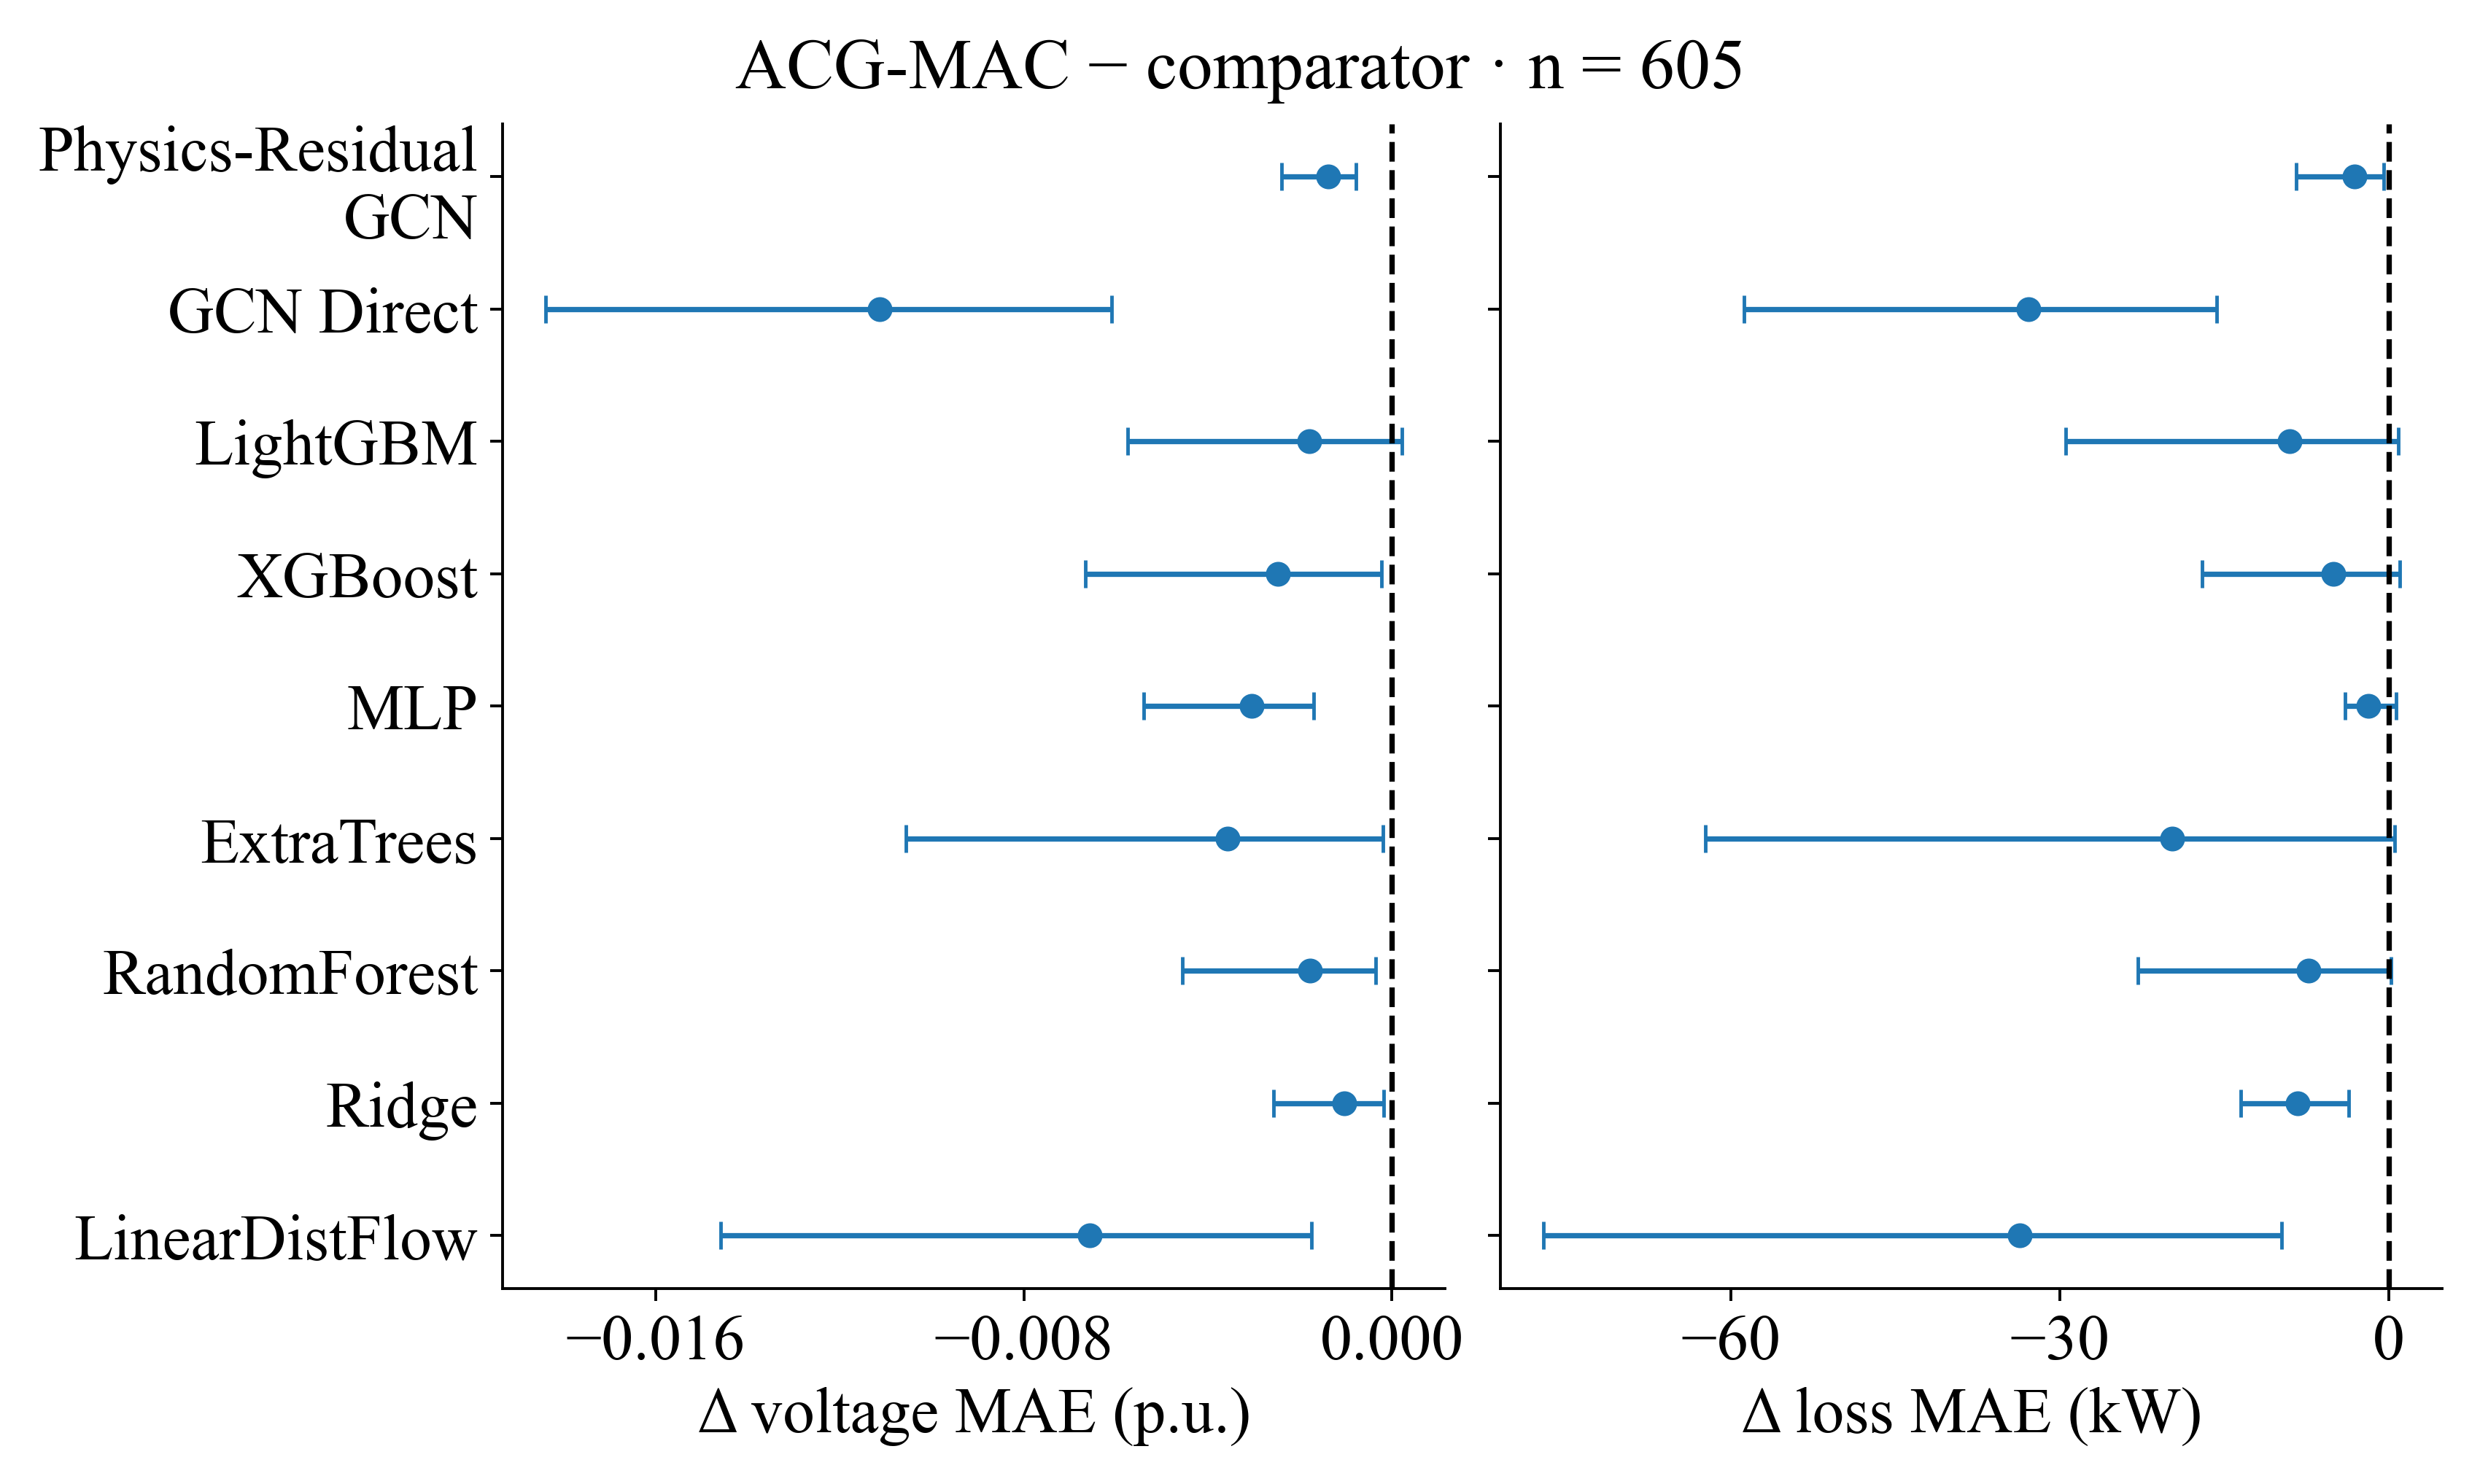

In [10]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(9.5, 5.6), layout="constrained")
for axis, target, label in zip(
    axes,
    ["Vmin MAE", "Loss MAE kW"],
    ["Δ voltage MAE (p.u.)", "Δ loss MAE (kW)"],
):
    group = statistics[statistics.target.eq(target)]
    center = group.mean_difference.to_numpy()
    axis.errorbar(
        center,
        np.arange(len(group)),
        xerr=np.vstack(
            [np.maximum(0, center - group.ci_low), np.maximum(0, group.ci_high - center)]
        ),
        fmt="o",
        capsize=4,
    )
    axis.axvline(0, color="black", linestyle="--")
    labels = group.baseline.str.replace(
        "Physics-Residual GCN", "Physics-Residual\nGCN", regex=False
    )
    axis.set_yticks(np.arange(len(group)), labels)
    axis.set(xlabel=label)
from matplotlib.ticker import MaxNLocator

for panel in axes:
    panel.xaxis.set_major_locator(MaxNLocator(nbins=3))
fig.suptitle("ACG-MAC − comparator · n = 605", fontsize=20)
save_figure(fig, FIGURES / "S6_Paired_effect_intervals.png")
plt.show()

Negative paired differences favor ACG-MAC. Voltage and loss effects have separate physical units; intervals crossing zero leave the sign of the difference uncertain.

## Computational trade-offs

Predictive performance is accompanied by the cost of the complete predictors.

In [11]:
efficiency = pd.read_csv(RESULTS / "efficiency.csv")
import joblib

mlp_regressor, mlp_classifier = joblib.load(MODELS / "MLP.joblib")
fitted_networks = [
    mlp_regressor.regressor_.named_steps["mlpregressor"],
    mlp_classifier.named_steps["mlpclassifier"],
]
mlp_parameters = sum(
    weights.size + biases.size
    for network in fitted_networks
    for weights, biases in zip(network.coefs_, network.intercepts_, strict=True)
)
efficiency.loc[efficiency.model.eq("MLP"), "trainable_parameters"] = mlp_parameters
efficiency["observations_per_second"] = 1000 / efficiency.inference_ms

show_table(
    efficiency,
    ["model", "split", "n"],
    {
        "Measured time": [
            "train_time_s",
            "inference_ms",
            "inference_iqr_ms",
            "inference_relative_to_ridge",
            "observations_per_second",
        ],
        "Process memory and serialized size": [
            "peak_process_rss_mib",
            "added_rss_mib",
            "serialized_mib",
        ],
        "Neural capacity": ["trainable_parameters"],
    },
    TABLES / "07_efficiency.csv",
    digits=6,
)

model,split,n,train_time_s,inference_ms,inference_iqr_ms,inference_relative_to_ridge,observations_per_second
LinearDistFlow,test,618,0.000020,0.000015,0.000004,0.024660,6.591970e+07
Ridge,test,618,0.008005,0.000615,0.000196,1.000000,1.625606e+06
RandomForest,test,618,2.244683,0.052656,0.000462,85.597478,18991.280267
ExtraTrees,test,618,1.095899,0.063714,0.000095,103.573944,15695.122112
MLP,test,618,0.890773,0.000980,0.000324,1.593601,1.020083e+06
XGBoost,test,618,0.557154,0.006495,0.000198,10.558546,153961.135811
LightGBM,test,618,0.409826,0.056031,0.000357,91.083786,17847.366226
GCN Direct,test,618,5.023195,0.061780,0.001565,100.429596,16186.520247
Physics-Residual GCN,test,618,2.874071,0.058112,0.006224,94.467506,17208.093743
ACG-MAC Ensemble,test,618,22.704419,0.402646,0.010677,654.544235,2483.568881


MLP capacity is counted from both fitted regression and classification networks. Latency is in milliseconds per observation and throughput is batch-amortized. Timing covers warmed prediction from prepared inputs, not sensor acquisition, graph/proxy construction or hardware switching. The ensemble's total member cost is retained; process RSS is not model-isolated memory.

## Decision and abstention outcomes

Action quality is reported together with abstention and numerical verification work.

In [12]:
decisions = pd.read_csv(RESULTS / "decisions.csv")
show_table(
    decisions,
    ["model", "split", "n"],
    {
        "Numerical acceptance": ["raw_feasible_rate", "executed_n", "abstention_rate"],
        "Conditional action quality": ["top1_given_execution", "mean_regret_given_execution"],
        "Verification work": ["mean_exact_checks"],
    },
    TABLES / "07_decisions.csv",
    digits=6,
)

Normal and fault episodes are reported separately. Regret and agreement are conditional on execution; abstentions remain visible. Numerical voltage feasibility is enforced by the shared physical filter, not claimed as a learned safety guarantee.

## Same-feeder external comparison

All fixed models are evaluated on identical external states without local labels.

In [13]:
external_rows = []
external_indices = indices["external"]
external_valid = external_indices[metadata.iloc[external_indices].converged.to_numpy() == 1]
for name in MODEL_ORDER:
    external_prediction, _ = load_predictions(name)
    external_rows.append(
        dict(
            model=name,
            split="external zero-shot converged",
            n=len(external_valid),
            **regression_metrics(
                bundle.targets[external_valid], external_prediction[external_valid]
            )
        )
    )
external_comparison = pd.DataFrame(external_rows)
show_table(
    external_comparison,
    ["model", "split", "n"],
    {
        "External voltage (errors ↓, R² ↑)": ["vmin_rmse", "vmin_mae", "vmin_r2"],
        "External losses (errors ↓, R² ↑)": ["loss_rmse_kw", "loss_mae_kw", "loss_r2"],
    },
    TABLES / "07_external_comparison.csv",
    digits=6,
)

model,split,n,vmin_rmse,vmin_mae,vmin_r2
LinearDistFlow,external zero-shot converged,800,0.003116,0.002424,0.985643
Ridge,external zero-shot converged,800,0.015600,0.015446,0.640067
RandomForest,external zero-shot converged,800,0.002247,0.001547,0.992529
ExtraTrees,external zero-shot converged,800,0.007794,0.007061,0.910153
MLP,external zero-shot converged,800,0.065156,0.057574,−5.279262
XGBoost,external zero-shot converged,800,0.008844,0.008378,0.884314
LightGBM,external zero-shot converged,800,0.003088,0.002733,0.985896
GCN Direct,external zero-shot converged,800,15.408306,15.408289,−351158.168282
Physics-Residual GCN,external zero-shot converged,800,2.231873,2.231820,−7366.722448
ACG-MAC Ensemble,external zero-shot converged,800,0.440555,0.440403,−286.074139


Every fixed model is scored on the same external states without local fitting. This single-feeder comparison characterizes transfer failure or recovery relative to the physical approximation; it cannot establish population-level network generalization. The separately reported supervised adaptation uses a disjoint 720-state test.

## External supervised adaptation

Local adaptation and zero-shot predictions share the same external test states.

In [14]:
transfer = pd.read_csv(RESULTS / "external_transfer.csv")
show_table(
    transfer,
    ["model", "split", "n"],
    {
        "Local supervision": ["local_fit_n", "local_calibration_n"],
        "Voltage (errors ↓, R² ↑)": ["vmin_rmse", "vmin_mae", "vmin_r2"],
        "Losses (errors ↓, R² ↑)": ["loss_rmse_kw", "loss_mae_kw", "loss_r2"],
    },
    TABLES / "07_external.csv",
    digits=6,
)

The locally supervised model and zero-shot ensemble use identical external test states. Local fitting and calibration require labels; their benefit is not evidence of universal zero-shot transfer.

## Limitations

- Data are balanced steady-state simulations from two feeder families. Field telemetry, unbalanced transients and chronological restoration are outside the dataset.
- The primary test contains nine topologies and was examined during model development. Training-only OOF evaluation addresses topology variation but does not provide a blinded multi-network test.
- Nonconverged power-flow states lack accepted regression labels. Their inadmissible classification is conservative and does not establish physical infeasibility.
- Equipment thermal ratings, protection coordination, switching transients and utility reliability or economic outcomes are not evaluated.
- Some ablations improve regression. Internal weights and conditional permutation effects do not establish causality.
- Statistical inference has nine independent test groups. Seed repeats measure optimization variability, not variation across network populations.
- Residual intervals can under-cover under topology shift; the external local-calibration subset is small.
- Graph comparators cover the implemented control family rather than all possible methods.
- Timings exclude feature construction and communication. Process RSS is not isolated deployment memory.

In [15]:
final_regression.to_csv(RESULTS / "final_regression.csv", index=False)
final_probability.to_csv(RESULTS / "final_probability.csv", index=False)